# ADR dataset generation (paper-aligned)

This notebook generates the **2D ADR** dataset used in this repo, aligned with the paper’s time discretization:

- **FOM:** `Nt_steps_fom = 1000` time steps on `[0, 10π]` ⇒ `Nt_points_fom = 1001` snapshots (including endpoints).
- **Training (coarse):** `Δt_train = 5 Δt_FOM` ⇒ `stride_train = 5` and `Nt_points_train = 201` coarse snapshots.
- **Time splits (for reporting):** `T1 = 4π`, `T2 = 5π`.

## Cell 0 — Environment notes (Fenicsx)

In [1]:
# conda create -n fenicsx -c conda-forge -y python=3.11 fenics-dolfinx mpich h5py mpi4py petsc petsc4py tqdm matplotlib
# conda activate fenicsx
# python -m ipykernel install --user --name fenicsx --display-name "Python (fenicsx)"

## Cell 1 — Imports + MPI sanity check

In [3]:
import numpy as np
import h5py
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from mpi4py import MPI
from petsc4py import PETSc

import ufl
from dolfinx import mesh, fem
from dolfinx.fem.petsc import assemble_matrix, assemble_vector

comm = MPI.COMM_WORLD
if comm.size != 1:
    raise RuntimeError("Please run dataset generation with MPI size 1 for this notebook version.")

/venv/fenicsx/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 — Time grids and paper-aligned splits

In [4]:
# ---------------------------
# Time configuration (paper-aligned)
# ---------------------------
T = 10.0 * np.pi
T1 = (2.0 / 5.0) * T   # = 4π
T2 = (1.0 / 2.0) * T   # = 5π

# Paper: 1000 time-steps over [0, T]  => 1001 snapshots including t=0 and t=T
Nt_steps_fom  = 1000
Nt_points_fom = Nt_steps_fom + 1
dt_fom = T / Nt_steps_fom

t_fine = np.linspace(0.0, T, Nt_points_fom, dtype=np.float64)
assert np.isclose(t_fine[-1], T)

# Training uses coarse snapshots every 5 FOM steps: Δt_train = 5 Δt_FOM
stride_train = 5
assert Nt_steps_fom % stride_train == 0

Nt_steps_train  = Nt_steps_fom // stride_train   # 200
Nt_points_train = Nt_steps_train + 1             # 201
dt_train = stride_train * dt_fom

idx_coarse_from_fine = np.arange(0, Nt_points_fom, stride_train, dtype=np.int32)
t_coarse = t_fine[idx_coarse_from_fine]

assert len(t_coarse) == Nt_points_train
assert np.isclose(t_coarse[-1], T)
assert np.isclose(t_coarse[1] - t_coarse[0], dt_train)

# Indices for T1, T2 on both grids (they land exactly on-grid here)
def idx_on_grid(t_grid: np.ndarray, t_target: float, name: str) -> int:
    i = int(np.round(t_target / (t_grid[1] - t_grid[0])))
    err = abs(t_grid[i] - t_target)
    if err > 1e-12:
        raise ValueError(f"{name} not on grid: |t[{i}] - {name}| = {err}")
    return i

iT1_fine   = idx_on_grid(t_fine,   T1, "T1")
iT2_fine   = idx_on_grid(t_fine,   T2, "T2")
iT1_coarse = idx_on_grid(t_coarse, T1, "T1")
iT2_coarse = idx_on_grid(t_coarse, T2, "T2")

# Fine (for reporting / evaluation)
fine_ids_train  = np.arange(0, iT1_fine + 1, dtype=np.int32)              # [0, T1]
fine_ids_interp = np.arange(iT1_fine + 1, iT2_fine + 1, dtype=np.int32)   # (T1, T2]
fine_ids_extrap = np.arange(iT2_fine + 1, Nt_points_fom, dtype=np.int32)  # (T2, T]

# Coarse (for training loop)
coarse_ids_train    = np.arange(0, iT1_coarse + 1, dtype=np.int32)        # [0, T1]
coarse_ids_val_loop = np.arange(iT1_coarse + 1, Nt_points_train, dtype=np.int32)  # (T1, T]

print("ADR time setup (paper-aligned)")
print(f"T={T:.6f}, T1={T1:.6f} (fine {iT1_fine}, coarse {iT1_coarse}), "
      f"T2={T2:.6f} (fine {iT2_fine}, coarse {iT2_coarse})")
print(f"FOM:   steps={Nt_steps_fom}, points={Nt_points_fom}, dt={dt_fom:.8f}")
print(f"TRAIN: steps={Nt_steps_train}, points={Nt_points_train}, dt={dt_train:.8f} (stride={stride_train})")

ADR time setup (paper-aligned)
T=31.415927, T1=12.566371 (fine 400, coarse 80), T2=15.707963 (fine 500, coarse 100)
FOM:   steps=1000, points=1001, dt=0.03141593
TRAIN: steps=200, points=201, dt=0.15707963 (stride=5)


## Cell 3 — Parameter sets (train / interp / extrap)

In [5]:
rng = np.random.default_rng(0)

# Full parameter box P = [1e-2, 6e-2] x [0.3,0.7]^2
P_lo = np.array([1e-2, 0.3, 0.3], dtype=float)
P_hi = np.array([6e-2, 0.7, 0.7], dtype=float)

# Inner "train-box" = [2e-2, 5e-2] x [0.4,0.6]^2
train_lo = np.array([2e-2, 0.4, 0.4], dtype=float)
train_hi = np.array([5e-2, 0.6, 0.6], dtype=float)

# Training grid: 10 points per dimension => 1000
grid_mu1 = np.linspace(train_lo[0], train_hi[0], 10)
grid_mu2 = np.linspace(train_lo[1], train_hi[1], 10)
grid_mu3 = np.linspace(train_lo[2], train_hi[2], 10)
MU_train = np.array([(a, b, c) for a in grid_mu1 for b in grid_mu2 for c in grid_mu3], dtype=float)
assert MU_train.shape == (1000, 3)

# Validation split: 20% of training parameters
perm_idx = rng.permutation(len(MU_train))
n_val = int(0.2 * len(MU_train))
idx_val = np.sort(perm_idx[:n_val])
idx_tr  = np.sort(perm_idx[n_val:])

# Interpolation test: midpoints (9 per dim => 729)
mid_mu1 = 0.5 * (grid_mu1[:-1] + grid_mu1[1:])
mid_mu2 = 0.5 * (grid_mu2[:-1] + grid_mu2[1:])
mid_mu3 = 0.5 * (grid_mu3[:-1] + grid_mu3[1:])
MU_interp = np.array([(a, b, c) for a in mid_mu1 for b in mid_mu2 for c in mid_mu3], dtype=float)
assert MU_interp.shape == (729, 3)

# Extrapolation: N points uniformly from P \ inner_box (rejection sampling)
def in_inner_box(mu: np.ndarray) -> bool:
    return np.all(mu >= train_lo) and np.all(mu <= train_hi)

N_extrap = 200
MU_extrap = []
while len(MU_extrap) < N_extrap:
    mu = rng.uniform(P_lo, P_hi)
    if not in_inner_box(mu):
        MU_extrap.append(mu)
MU_extrap = np.array(MU_extrap, dtype=float)

print("Train/Interp/Extrap:", MU_train.shape, MU_interp.shape, MU_extrap.shape)
print("Train idx:", len(idx_tr), " Val idx:", len(idx_val))

Train/Interp/Extrap: (1000, 3) (729, 3) (200, 3)
Train idx: 800  Val idx: 200


## Cell 4 — Spatial mesh, DoF ordering, and vector→grid mapping

In [6]:
# 32 nodes per side => 31 subdivisions in each direction
nx = ny = 31
domain = mesh.create_unit_square(comm, nx, ny, cell_type=mesh.CellType.triangle)

V = fem.functionspace(domain, ("Lagrange", 1))
Ndof = V.dofmap.index_map.size_global
print("Ndof global:", Ndof)
assert Ndof == 1024, "Expected 1024 DoFs (32x32 nodes). Check mesh resolution."

# DoF coordinates and stable ordering (sort by y then x) so we can reshape to (32,32)
dof_coords = V.tabulate_dof_coordinates().reshape((Ndof, -1))
coords_xy = dof_coords[:, :2]

perm = np.lexsort((coords_xy[:, 0], coords_xy[:, 1]))  # sort by y then x
coord_grid = coords_xy[perm].reshape((ny + 1, nx + 1, 2))

print("coord_grid shape:", coord_grid.shape)
if dof_coords.shape[1] >= 3:
    print("max |z| (should be 0):", float(np.abs(dof_coords[:, 2]).max()))

def vec_to_grid(u_vec: np.ndarray) -> np.ndarray:
    """u_vec (1024,) -> grid (32,32) sorted by y then x."""
    u_sorted = u_vec[perm]
    return u_sorted.reshape((ny + 1, nx + 1))

Ndof global: 1024
coord_grid shape: (32, 32, 2)
max |z| (should be 0): 0.0


## Cell 5 — ADR variational problem (Backward Euler)

In [7]:
# Reaction coefficient (paper uses c=1)
c_react = 1.0

# Trial/test functions
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Parameters as dolfinx Constants (updated per trajectory / timestep)
mu1 = fem.Constant(domain, PETSc.ScalarType(2e-2))                       # diffusion
c   = fem.Constant(domain, PETSc.ScalarType(c_react))                    # reaction
dt  = fem.Constant(domain, PETSc.ScalarType(dt_fom))                     # timestep (FOM)

# Time-dependent advection b(t) = (cos t, sin t)
b = fem.Constant(domain, np.array([1.0, 0.0], dtype=PETSc.ScalarType))

# Gaussian source location parameters (mu2, mu3)
mu2 = fem.Constant(domain, PETSc.ScalarType(0.5))
mu3 = fem.Constant(domain, PETSc.ScalarType(0.5))

x = ufl.SpatialCoordinate(domain)
f = 10.0 * ufl.exp(-(((x[0] - mu2)**2 + (x[1] - mu3)**2) / 0.072))

# Unknowns at n and n+1
u_n   = fem.Function(V)  # initialized to 0
u_np1 = fem.Function(V)

# Backward Euler weak form:
a_form = (u/dt) * v * ufl.dx          + mu1 * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx          + ufl.dot(b, ufl.grad(u)) * v * ufl.dx          + c * u * v * ufl.dx

L_form = (u_n/dt) * v * ufl.dx + f * v * ufl.dx

# PETSc solver (serial LU)
ksp = PETSc.KSP().create(comm)
ksp.setType("preonly")
pc = ksp.getPC()
pc.setType("lu")
ksp.setFromOptions()

## Cell 6 — Solve one trajectory (fine + coarse)

In [8]:
def solve_one_trajectory(mu: np.ndarray, store_float32: bool = True):
    """
    Solve ADR FOM for one parameter mu=(mu1,mu2,mu3).

    Returns:
      U_fine:   (Nt_points_fom, 32, 32)  float32/float64
      U_coarse: (Nt_points_train, 32, 32) every stride_train step
    """
    mu1.value = PETSc.ScalarType(float(mu[0]))
    mu2.value = PETSc.ScalarType(float(mu[1]))
    mu3.value = PETSc.ScalarType(float(mu[2]))

    # Reset initial condition u(x,0)=0
    u_n.x.array[:] = 0.0
    u_n.x.scatter_forward()

    dtype = np.float32 if store_float32 else np.float64
    U_fine = np.empty((Nt_points_fom, ny + 1, nx + 1), dtype=dtype)

    # store t=0
    U_fine[0] = vec_to_grid(u_n.x.array.copy()).astype(dtype, copy=False)

    for n in range(Nt_points_fom - 1):
        t_np1 = float(t_fine[n + 1])
        b.value = np.array([np.cos(t_np1), np.sin(t_np1)], dtype=PETSc.ScalarType)

        # Assemble matrix + RHS
        A = assemble_matrix(fem.form(a_form))
        A.assemble()

        bvec = assemble_vector(fem.form(L_form))
        bvec.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)

        # Solve
        ksp.setOperators(A)
        ksp.solve(bvec, u_np1.x.petsc_vec)
        u_np1.x.scatter_forward()

        # advance
        u_n.x.array[:] = u_np1.x.array
        u_n.x.scatter_forward()

        U_fine[n + 1] = vec_to_grid(u_n.x.array.copy()).astype(dtype, copy=False)

        # cleanup PETSc objects
        A.destroy()
        bvec.destroy()

    U_coarse = U_fine[idx_coarse_from_fine]
    return U_fine, U_coarse

## Cell 7 — Create HDF5 (paper-aligned metadata + backward-compatible keys)

In [9]:
def create_h5(path: str,
              MU_train: np.ndarray,
              MU_interp: np.ndarray,
              MU_extrap: np.ndarray,
              idx_tr: np.ndarray,
              idx_val: np.ndarray,
              coord_grid: np.ndarray):
    """
    Creates an HDF5 file with:
      - root datasets: t_fine, t_coarse, coord_grid (backward compatible)
      - groups: train / interp / extrap each with mu, u_fine, u_coarse
      - groups: time / splits with explicit indices for aligned training/eval
      - attrs: paper-aligned discretization metadata
    """
    with h5py.File(path, "w") as h5:
        # --------- attrs (scalars) ---------
        h5.attrs["problem"] = "ADR"
        h5.attrs["T"] = float(T)
        h5.attrs["T1"] = float(T1)
        h5.attrs["T2"] = float(T2)

        h5.attrs["Nt_steps_fom"] = int(Nt_steps_fom)
        h5.attrs["Nt_points_fom"] = int(Nt_points_fom)
        h5.attrs["dt_fom"] = float(dt_fom)

        h5.attrs["stride_train"] = int(stride_train)
        h5.attrs["Nt_steps_train"] = int(Nt_steps_train)
        h5.attrs["Nt_points_train"] = int(Nt_points_train)
        h5.attrs["dt_train"] = float(dt_train)

        h5.attrs["iT1_fine"] = int(iT1_fine)
        h5.attrs["iT2_fine"] = int(iT2_fine)
        h5.attrs["iT1_coarse"] = int(iT1_coarse)
        h5.attrs["iT2_coarse"] = int(iT2_coarse)

        # Parameter boxes (provenance)
        h5.create_dataset("P_lo", data=P_lo.astype(np.float64))
        h5.create_dataset("P_hi", data=P_hi.astype(np.float64))
        h5.create_dataset("train_lo", data=train_lo.astype(np.float64))
        h5.create_dataset("train_hi", data=train_hi.astype(np.float64))

        # --------- backward-compatible root datasets ---------
        h5.create_dataset("t_fine", data=t_fine.astype(np.float64))
        h5.create_dataset("t_coarse", data=t_coarse.astype(np.float64))
        h5.create_dataset("coord_grid", data=coord_grid.astype(np.float64))  # (32,32,2)

        # --------- structured metadata ---------
        g_time = h5.create_group("time")
        g_time.create_dataset("t_fine", data=t_fine.astype(np.float32), compression="gzip", compression_opts=4)
        g_time.create_dataset("t_coarse", data=t_coarse.astype(np.float32), compression="gzip", compression_opts=4)
        g_time.create_dataset("idx_coarse_from_fine", data=idx_coarse_from_fine, compression="gzip", compression_opts=4)

        g_splits = h5.create_group("splits")
        g_splits.create_dataset("coarse_ids_train", data=coarse_ids_train, compression="gzip", compression_opts=4)
        g_splits.create_dataset("coarse_ids_val_loop", data=coarse_ids_val_loop, compression="gzip", compression_opts=4)
        g_splits.create_dataset("fine_ids_train", data=fine_ids_train, compression="gzip", compression_opts=4)
        g_splits.create_dataset("fine_ids_interp", data=fine_ids_interp, compression="gzip", compression_opts=4)
        g_splits.create_dataset("fine_ids_extrap", data=fine_ids_extrap, compression="gzip", compression_opts=4)

        # --------- parameter groups ---------
        def make_group(name: str, MU: np.ndarray):
            g = h5.create_group(name)
            g.create_dataset("mu", data=MU.astype(np.float64))

            N = MU.shape[0]
            chunks_fine = (1, 10, ny + 1, nx + 1)
            chunks_coarse = (1, 10, ny + 1, nx + 1)

            g.create_dataset(
                "u_fine",
                shape=(N, Nt_points_fom, ny + 1, nx + 1),
                dtype=np.float32,
                chunks=chunks_fine,
                compression="gzip",
                compression_opts=4,
            )
            g.create_dataset(
                "u_coarse",
                shape=(N, Nt_points_train, ny + 1, nx + 1),
                dtype=np.float32,
                chunks=chunks_coarse,
                compression="gzip",
                compression_opts=4,
            )

        make_group("train", MU_train)
        make_group("interp", MU_interp)
        make_group("extrap", MU_extrap)

        # Train/val split indices (over MU_train)
        h5.create_dataset("train_idx", data=idx_tr.astype(np.int64))
        h5.create_dataset("val_idx", data=idx_val.astype(np.int64))

    print(f"Created HDF5 dataset at: {path}")

## Cell 8 — Fill groups (generate trajectories and write to HDF5)

In [10]:
def fill_group(h5: h5py.File, group_name: str, max_items=None):
    g = h5[group_name]
    MU = g["mu"][:]
    N = MU.shape[0] if max_items is None else min(max_items, MU.shape[0])

    for i in tqdm(range(N), desc=f"Generating {group_name}", leave=True):
        U_fine, U_coarse = solve_one_trajectory(MU[i], store_float32=True)
        g["u_fine"][i, ...] = U_fine
        g["u_coarse"][i, ...] = U_coarse

## Cell 9 — Generate dataset (choose output path + run)

In [11]:
out_path = "adr_full.h5"

# 1) Create empty file (fast)
create_h5(out_path, MU_train, MU_interp, MU_extrap, idx_tr, idx_val, coord_grid)

# 2) Fill with trajectories (slow)
with h5py.File(out_path, "a") as h5:
    fill_group(h5, "train")
    fill_group(h5, "interp")
    fill_group(h5, "extrap")

Created HDF5 dataset at: adr_full.h5


Generating extrap: 100%|██████████| 200/200 [17:30<00:00,  5.25s/it]


## Cell 10 — Smoke test + quick plots

mu: [0.02 0.4  0.4 ]
||u(0)|| = 0.0, max=0.0, min=0.0
||u(400)|| = 44.553016662597656, max=2.982245683670044, min=0.035245150327682495
||u(500)|| = 38.83615493774414, max=2.9951090812683105, min=0.1199142336845398
||u(1000)|| = 44.5530891418457, max=2.982248067855835, min=0.03524775430560112


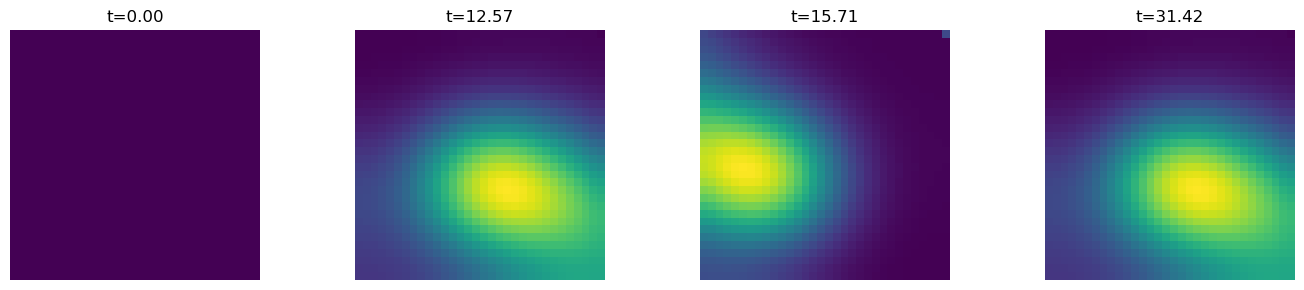

In [12]:
# Smoke test: load a single trajectory and plot a few times
idx = 0  # change as desired

with h5py.File(out_path, "r") as h5:
    U = h5["train/u_fine"][idx]   # (Nt_points_fom, 32, 32)
    mu = h5["train/mu"][idx]
    print("mu:", mu)

    times_to_plot = [0, iT1_fine, iT2_fine, Nt_points_fom - 1]
    for k in times_to_plot:
        print(f"||u({k})|| = {np.linalg.norm(U[k])}, max={np.max(U[k])}, min={np.min(U[k])}")

    fig, axs = plt.subplots(1, len(times_to_plot), figsize=(14, 3))
    for ax, k in zip(axs, times_to_plot):
        ax.imshow(U[k], origin="lower")
        ax.set_title(f"t={t_fine[k]:.2f}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()